# Redshift Scalar Tokenizer

This notebook demonstrates the CDF → Gaussian → FSQ scalar tokenization pipeline for DESI redshift values.

**Pipeline:**
1. **CDF**: Map redshift `z` to empirical cumulative distribution `P(Z ≤ z)`
2. **Gaussian**: Map CDF to standard normal via inverse CDF (`Φ⁻¹`)
3. **FSQ**: Quantize Gaussian to discrete levels (default 256 = 8 bits)

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.tokenizers.redshift import RedshiftTokenizer
from src.utils.data import DESISpectrumDataset

%matplotlib inline

## 1. Load DESI Redshift Data

In [2]:
files = sorted(Path('../data/desi_raw').glob('coadd-*.fits'))

all_z = []
for f in files:
    rr = f.parent / f.name.replace('coadd-', 'redrock-')
    ds = DESISpectrumDataset(coadd_path=f, redrock_path=rr,
                             require_good_zwarn=False, require_nonzero_flux=True)
    for i in range(len(ds)):
        all_z.append(ds[i]['z'].item())

all_z = np.array(all_z)
print(f"Total spectra: {len(all_z)}")
print(f"Redshift range: [{all_z.min():.4f}, {all_z.max():.4f}]")
print(f"Mean: {all_z.mean():.4f}, Std: {all_z.std():.4f}, Median: {np.median(all_z):.4f}")

  Filtered out 10 bad spectra:
    10 zero flux
Loaded 33 good spectra from coadd-sv3-bright-10016.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
Loaded 5 good spectra from coadd-sv3-bright-10145.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
  Filtered out 27 bad spectra:
    27 zero flux
Loaded 123 good spectra from coadd-sv3-bright-10146.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
  Filtered out 4 bad spectra:
    4 zero flux
Loaded 108 good spectra from coadd-sv3-bright-10148.fits
  Wavelength range: [3600.0, 9824.0] Å
  Pixels per spectrum: 7781
Total spectra: 269
Redshift range: [-0.0010, 1.1854]
Mean: 0.0303, Std: 0.1212, Median: 0.0000


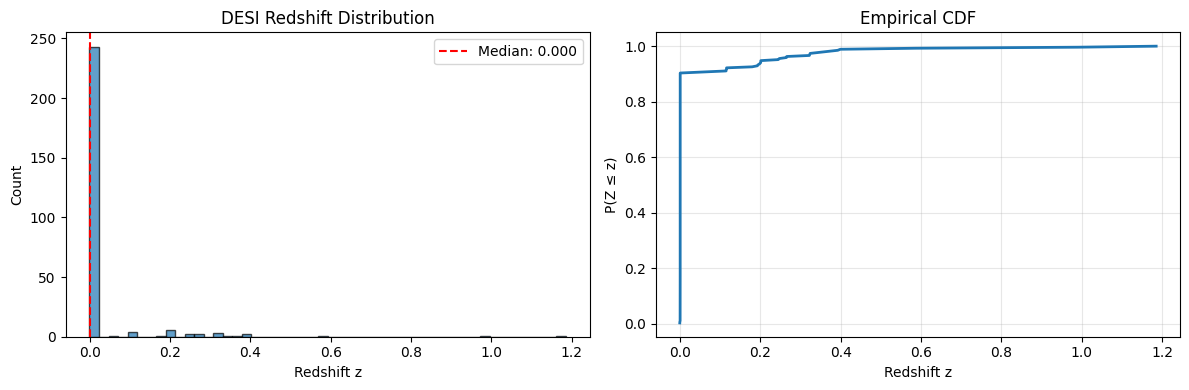

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(all_z, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Redshift z')
axes[0].set_ylabel('Count')
axes[0].set_title('DESI Redshift Distribution')
axes[0].axvline(np.median(all_z), color='red', linestyle='--', label=f'Median: {np.median(all_z):.3f}')
axes[0].legend()

# CDF
sorted_z = np.sort(all_z)
cdf = np.arange(1, len(sorted_z) + 1) / len(sorted_z)
axes[1].plot(sorted_z, cdf, linewidth=2)
axes[1].set_xlabel('Redshift z')
axes[1].set_ylabel('P(Z ≤ z)')
axes[1].set_title('Empirical CDF')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/redshift_distribution.png', dpi=150)
plt.show()

## 2. Fit Tokenizer and Show Transforms

In [4]:
tok = RedshiftTokenizer(n_levels=256)
tok.fit(all_z)

z_tensor = torch.tensor(all_z)

# Compute each stage
cdf_vals = tok._cdf(z_tensor).numpy()
gaussian_vals = tok.cdf_to_gaussian(torch.tensor(cdf_vals)).numpy()
indices = tok.encode(z_tensor).numpy()
z_recon = tok.decode(torch.tensor(indices)).numpy()

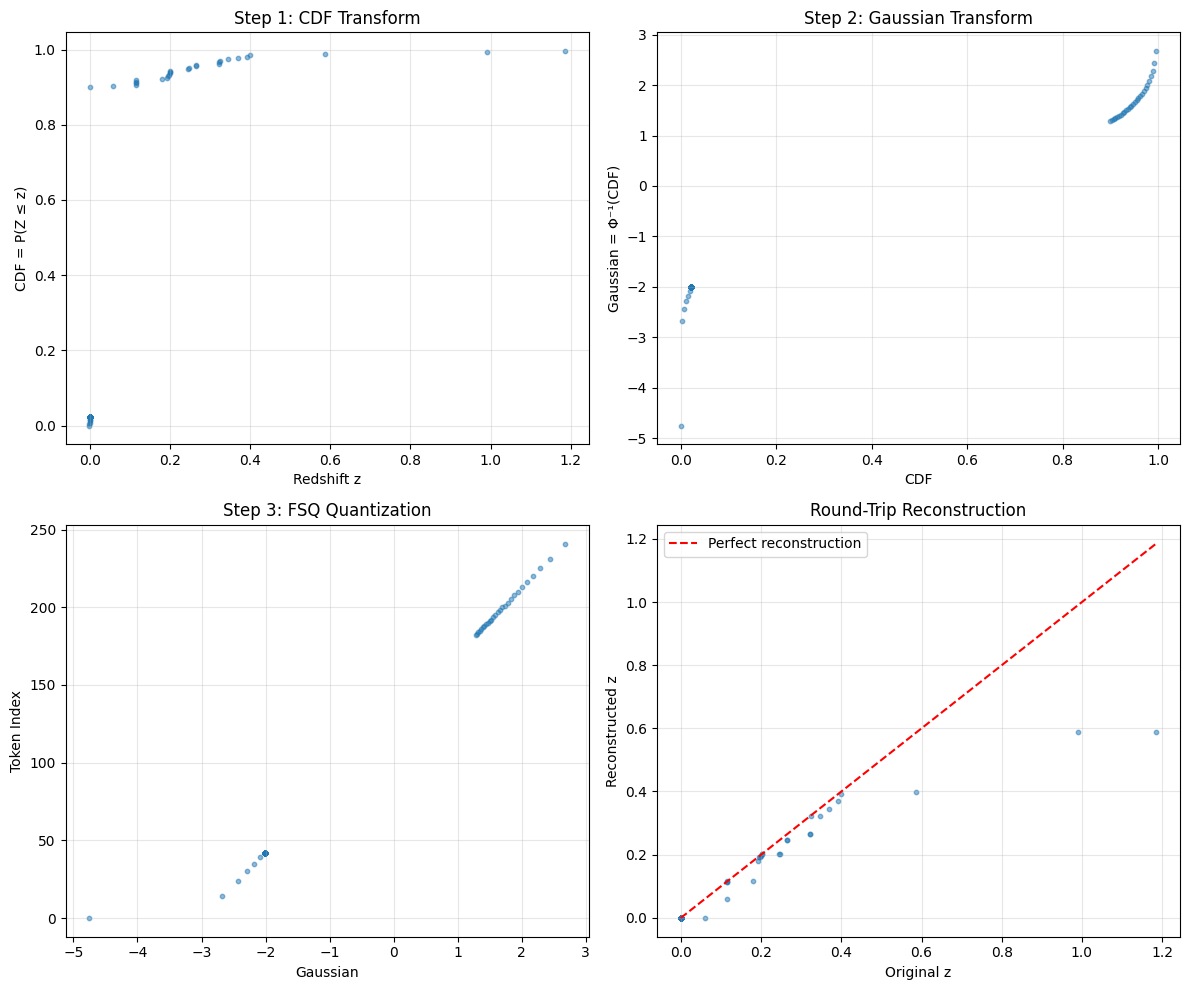

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# z -> CDF
axes[0, 0].scatter(all_z, cdf_vals, s=10, alpha=0.5)
axes[0, 0].set_xlabel('Redshift z')
axes[0, 0].set_ylabel('CDF = P(Z ≤ z)')
axes[0, 0].set_title('Step 1: CDF Transform')
axes[0, 0].grid(True, alpha=0.3)

# CDF -> Gaussian
axes[0, 1].scatter(cdf_vals, gaussian_vals, s=10, alpha=0.5)
axes[0, 1].set_xlabel('CDF')
axes[0, 1].set_ylabel('Gaussian = Φ⁻¹(CDF)')
axes[0, 1].set_title('Step 2: Gaussian Transform')
axes[0, 1].grid(True, alpha=0.3)

# Gaussian -> Token Index
axes[1, 0].scatter(gaussian_vals, indices, s=10, alpha=0.5)
axes[1, 0].set_xlabel('Gaussian')
axes[1, 0].set_ylabel('Token Index')
axes[1, 0].set_title('Step 3: FSQ Quantization')
axes[1, 0].grid(True, alpha=0.3)

# Original vs Reconstructed
axes[1, 1].scatter(all_z, z_recon, s=10, alpha=0.5)
axes[1, 1].plot([all_z.min(), all_z.max()], [all_z.min(), all_z.max()], 'r--', label='Perfect reconstruction')
axes[1, 1].set_xlabel('Original z')
axes[1, 1].set_ylabel('Reconstructed z')
axes[1, 1].set_title('Round-Trip Reconstruction')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/redshift_tokenizer_pipeline.png', dpi=150)
plt.show()

## 3. Quantization Bin Analysis

In [6]:
unique_indices = np.unique(indices)
utilization = len(unique_indices) / tok.n_levels
print(f"Token utilization: {utilization:.1%} ({len(unique_indices)}/{tok.n_levels})")

# Bin edges
edges = tok.get_bin_edges().numpy()
print(f"\nBin edges (first 10): {edges[:10]}")
print(f"Bin edges (last 10): {edges[-10:]}")

Token utilization: 13.3% (34/256)

Bin edges (first 10): [-0.00097189 -0.00097189 -0.00097189 -0.00097189 -0.00097189 -0.00097189
 -0.00097189 -0.00097189 -0.00097189 -0.00097189]
Bin edges (last 10): [0.99002534 0.99002534 0.99002534 0.99002534 0.99002534 0.99002534
 0.99002534 0.99002534 0.99002534 0.99002534]


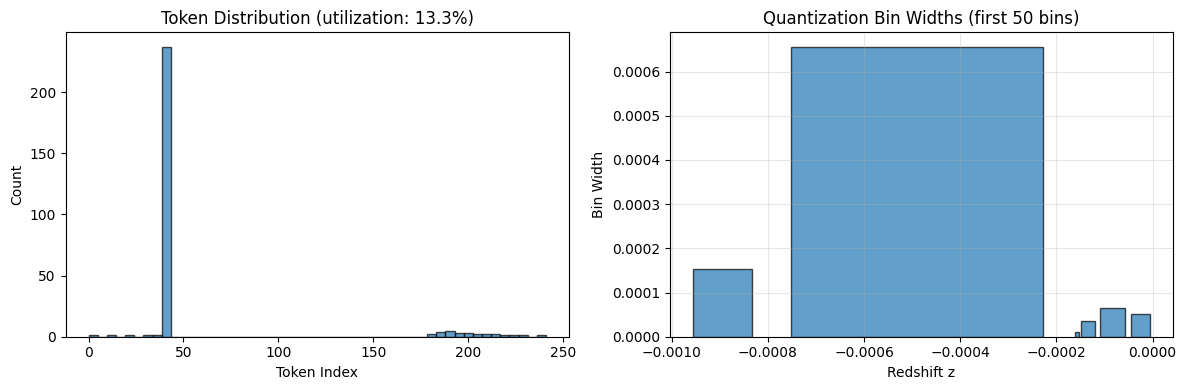

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Token index histogram
axes[0].hist(indices, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Token Index')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Token Distribution (utilization: {utilization:.1%})')

# Bin widths
bin_widths = np.diff(edges)
bin_centers = (edges[:-1] + edges[1:]) / 2
axes[1].bar(bin_centers[:50], bin_widths[:50], width=0.8*np.diff(edges[:51]), alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Redshift z')
axes[1].set_ylabel('Bin Width')
axes[1].set_title('Quantization Bin Widths (first 50 bins)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/redshift_token_bins.png', dpi=150)
plt.show()

## 4. Reconstruction Error Analysis

In [8]:
errors = np.abs(all_z - z_recon)
mae = errors.mean()
max_error = errors.max()

print(f"Mean Absolute Error: {mae:.6f}")
print(f"Max Absolute Error: {max_error:.6f}")

# Error by redshift range
ranges = [(0, 0.01, 'Stars'), (0.01, 0.5, 'Low-z galaxies'), (0.5, 2.0, 'High-z galaxies')]
for zmin, zmax, name in ranges:
    mask = (all_z >= zmin) & (all_z < zmax)
    if mask.sum() > 0:
        range_mae = errors[mask].mean()
        print(f"  {name} (z∈[{zmin}, {zmax})): MAE={range_mae:.6f}, n={mask.sum()}")

Mean Absolute Error: 0.006415
Max Absolute Error: 0.598250
  Stars (z∈[0, 0.01)): MAE=0.000051, n=237
  Low-z galaxies (z∈[0.01, 0.5)): MAE=0.022765, n=23
  High-z galaxies (z∈[0.5, 2.0)): MAE=0.396432, n=3


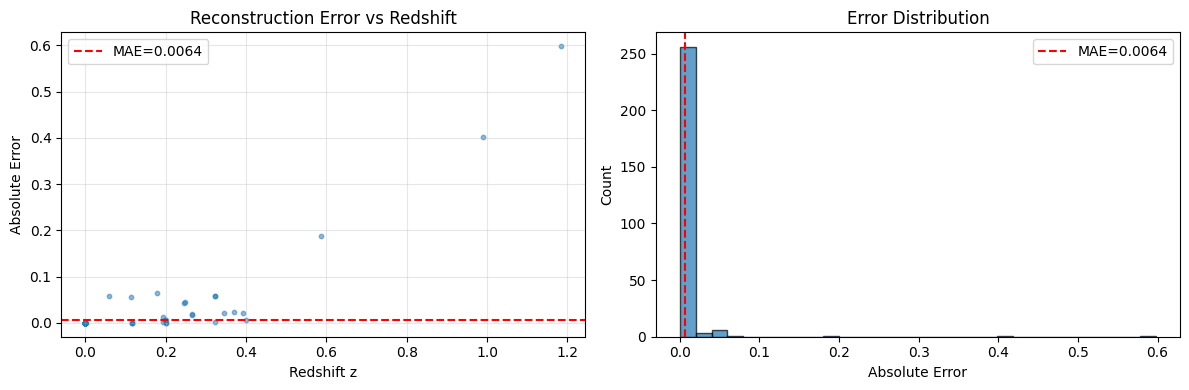

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Error vs redshift
axes[0].scatter(all_z, errors, s=10, alpha=0.5)
axes[0].set_xlabel('Redshift z')
axes[0].set_ylabel('Absolute Error')
axes[0].set_title('Reconstruction Error vs Redshift')
axes[0].axhline(mae, color='red', linestyle='--', label=f'MAE={mae:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error histogram
axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Absolute Error')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution')
axes[1].axvline(mae, color='red', linestyle='--', label=f'MAE={mae:.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../plots/redshift_reconstruction_error.png', dpi=150)
plt.show()

## 5. Summary

The redshift tokenizer successfully:
- Uses **{utilization:.1%}** of available quantization bins
- Achieves **MAE = {mae:.6f}** on the test set
- Handles the heavily skewed DESI distribution (mostly stars at z≈0)

Key design choices:
- **CDF transform** flattens the skewed distribution for uniform bin utilization
- **Gaussian transform** maps to a well-behaved space for quantization
- **256 levels** provides 8-bit precision, sufficient for redshift regression

The tokenizer will be integrated with the transformer as a special prepended token.